In [1]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scipy.optimize as optimize
import scipy.stats as stats
import seaborn as sns

# 1. Configuration stricte de la reproductibilité 
seed = 42
import os
import sys

os.environ["PYTHONHASHSEED"] = str(seed)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import random
import numpy as np

random.seed(seed)
np.random.seed(seed)

# Optionnel : Bloquer le multi-threading si on veut du 100% déterministe en CPU
# os.environ["MKL_NUM_THREADS"] = "1"
# os.environ["OMP_NUM_THREADS"] = "1"

import torch
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 2. Ajout du chemin pour les modules locaux
sys.path.append(os.path.abspath(".."))

# 3. Imports de la bibliothèque standard
import json
import math
import time
from pathlib import Path

# 4. Librairies tierces (Data Science, Visualisation, ML)
import joblib
import marimo as mo
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import polars as pl
import seaborn as sns
import tsfel
from sklearn.metrics import (
    brier_score_loss,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from joblib import Parallel, delayed
from collections import Counter
# 5. Imports locaux (modules customs)
import utilitaries.create_merged_dataset as create_merged_dataset
import utilitaries.extract_data_utils as extract
import utilitaries.features_extraction_utils as extract_feat
import utilitaries.marimo_utils as mo_utils
import utilitaries.optuna.optuna_utils as optuna_utils
import utilitaries.preprocessing_utils as preproc
import utilitaries.preprocessing_utils as ui
import utilitaries.path_utils as path_utils
import utilitaries.show_fig_utils as sfu
import utilitaries.timestamp_sampling_utils as tsu
import utilitaries.resampling_utils as resampling
from utilitaries.models.inceptionTimeModified import (
    evaluate_on_test,
    load_model_from_checkpoint,
    predict_proba,
    train_inception_time,
)
from utilitaries.models.lstmTimeModified import (
    evaluate_lstm_on_test,
    load_lstm_from_checkpoint,
    predict_proba_lstm,
    train_lstm_model,
)
pl.Config.set_tbl_cols(-1)

/home/paquie.d/Projet Stage M2/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


polars.config.Config

In [19]:

dataset_path = "/../../../data2/paquie.d/Datasets/output"
_path = os.path.join(dataset_path, "df_static_ano_clean.parquet")
df_static = pl.scan_parquet(_path)

_path = os.path.join(dataset_path, 'df_dynamic_full_clean.parquet')
df_dynamic = extract.extract_data_survie(_path)

df_merged = create_merged_dataset.create_merged_dataset(df_static, df_dynamic, True, save = True, folder = dataset_path)

df_merged_1 = tsu.prepare_labels(df_merged, "relative")
df_merged_1 = df_merged_1.filter(pl.col("delta_hour") >= 0)
df_merged_1 = df_merged_1.collect()


# ────────────────────────────────────────────────────────────────────────
# ÉTAPE 1 : SÉLECTION DES FEATURES ET NETTOYAGE (df_clean)
# ────────────────────────────────────────────────────────────────────────

# Pipeline de nettoyage Polars complet
df_clean = (
    df_merged_1.with_columns(
        [
            pl.col("is_ventilated").fill_null(pl.lit(False)),
            pl.col("is_prone").fill_null(pl.lit(False)),
            pl.col("is_conscious").fill_null(pl.lit(False)),
            pl.col("is_cvvhf").fill_null(pl.lit(False)),
            pl.col("is_hdi").fill_null(pl.lit(False)),
        ]
    )
    .filter(
        pl.col("taille").is_not_null() & pl.col("poids_admission").is_not_null()
    )
    .with_columns(
        [
            pl.col("delta_hour").min().over("encounterId").alias("min_h"),
            pl.col("delta_hour").max().over("encounterId").alias("max_h"),
        ]
    )
    .with_columns(pl.col("max_h").alias("duree_reelle_sejour"))
)
# ────────────────────────────────────────────────────────────────────────
# ÉTAPE 2 : ISOLEMENT DU COMPTE À REBOURS AVANT DÉCÈS
# ────────────────────────────────────────────────────────────────────────

df_deces = (
    df_clean.filter(
        pl.col("isDeceased_lt_24h").max().over("encounterId") == 1
    )
    .with_columns(
        pl.when(pl.col("isDeceased_lt_24h") == 1)
        .then(pl.col("delta_hour"))
        .otherwise(None)
        .min()
        .over("encounterId")
        .alias("heure_debut_crise")
    )
    .with_columns((pl.col("heure_debut_crise") + 24).alias("heure_deces_estimee"))
    .with_columns(
        (pl.col("heure_deces_estimee") - pl.col("delta_hour")).alias(
            "temps_restant_avant_deces"
        )
    )
)
df_deces2 = df_deces.filter(pl.col("temps_restant_avant_deces") >= 0).select("temps_restant_avant_deces", "encounterId")

data_deces = df_deces2["temps_restant_avant_deces"].to_numpy()

data_trie = np.sort(data_deces)

Plan de chargement des données dynamiques préparé (Lazy).


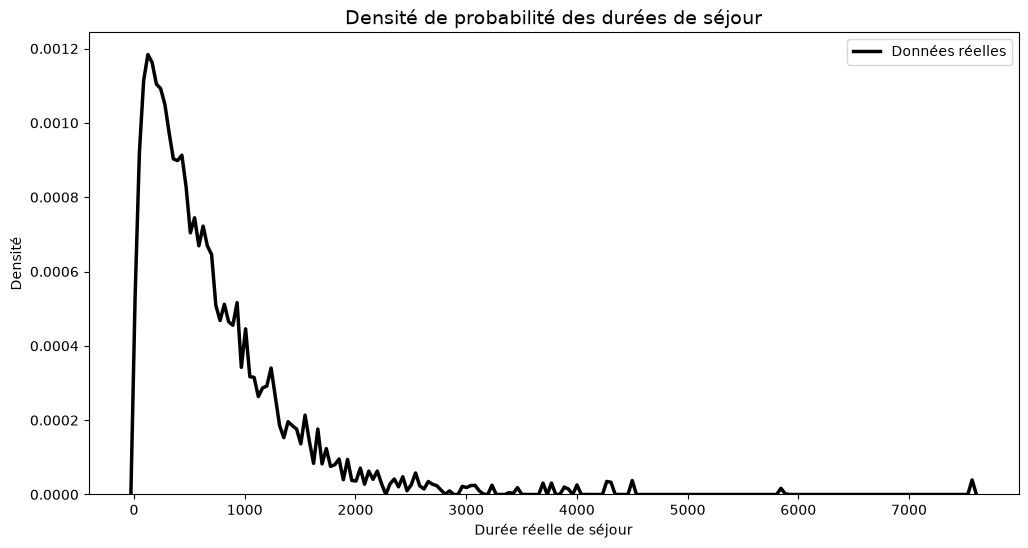

In [20]:
seuil_min = 0
df_secu = df_clean.filter(pl.col("duree_reelle_sejour") > seuil_min)
data = df_secu["duree_reelle_sejour"].to_numpy()

x = np.linspace(data.min(), data.max(), 1000)

plt.figure(figsize=(12, 6))

ax = sns.kdeplot(data, color="black", linewidth=2.5, label="Données réelles", bw_adjust=0.3)

# On récupère la hauteur max
y_max_reelle = ax.get_ylim()[1]

plt.title("Densité de probabilité des durées de séjour", fontsize=14)
plt.xlabel("Durée réelle de séjour")
plt.ylabel("Densité")
plt.legend()
plt.show()

Optimisation des paramètres en cours...

--- PARAMÈTRES FINAUX OPTIMISÉS ---
Lomax Réelle   : α = 4.3085, λ = 1161.9368
Weibull Réelle : c = 0.8920, scale = 310.0623
Exponentielle  : scale = 303.8153
Gamma          : a = 0.8384, scale = 384.9548
Log-Normale    : s = 1.2953, scale = 190.9385



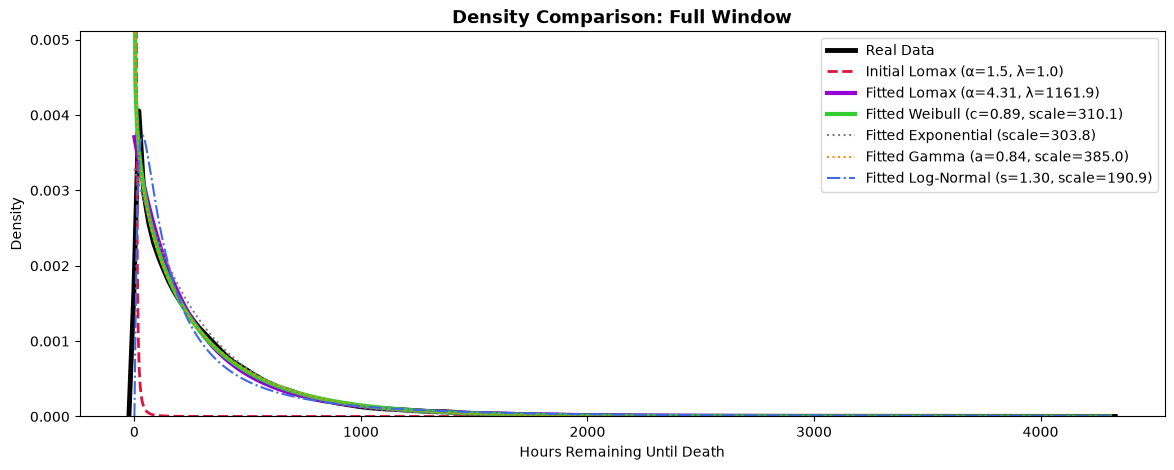

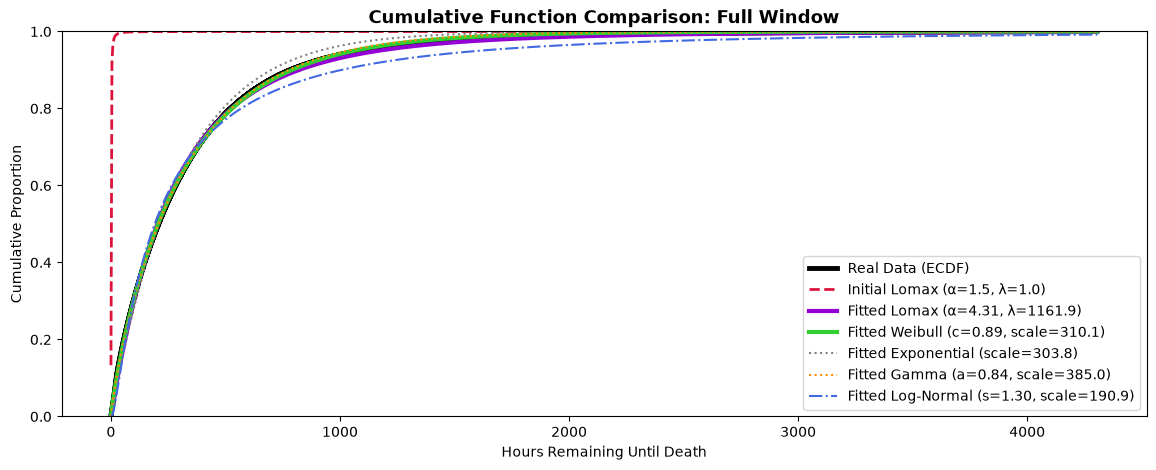

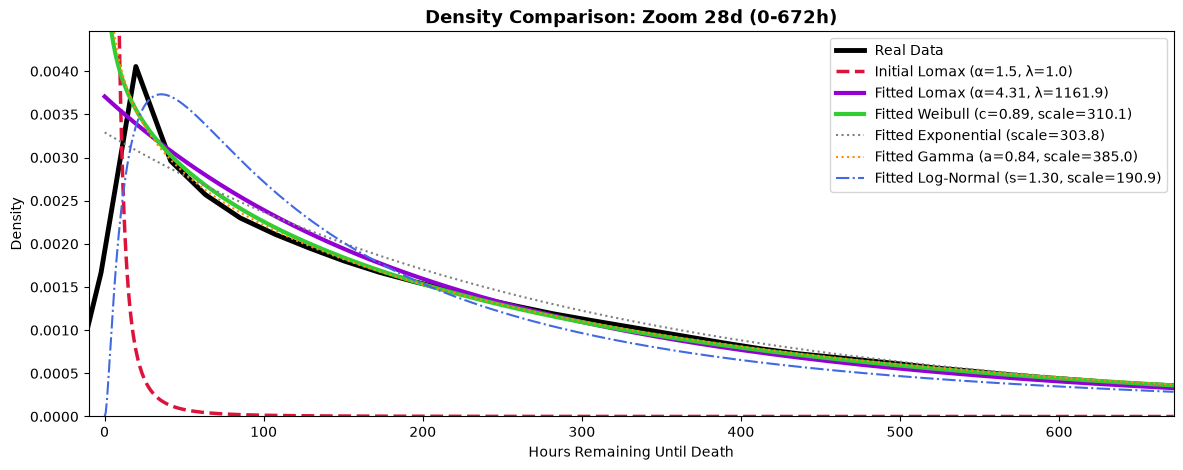

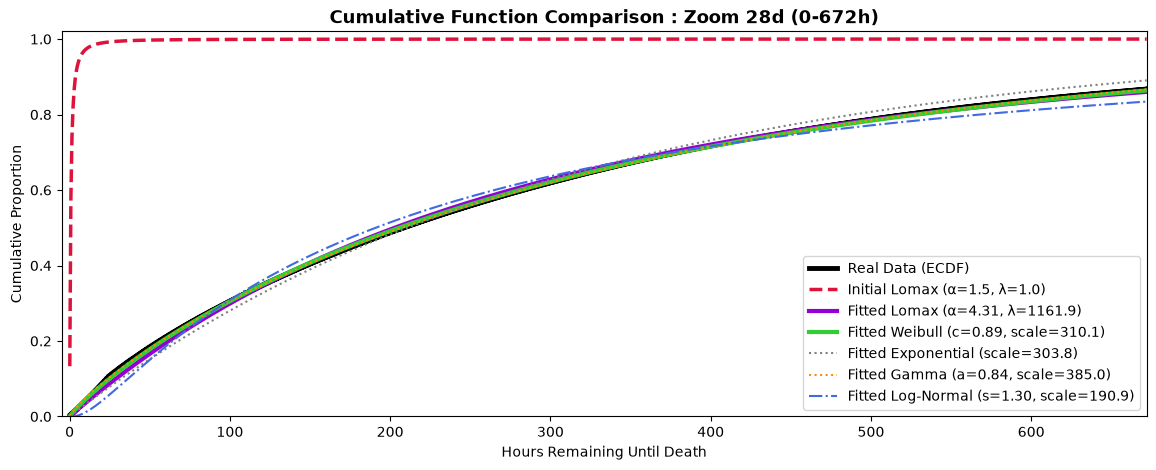

In [21]:

y_ecdf = np.arange(1, len(data_trie) + 1) / len(data_trie)

# Grilles X de tracé (on commence à 0.1 pour esquiver le Warning de division par zéro)
x_complet = np.linspace(0.1, data_deces.max(), 1000)
X_ZOOM_MAX = 672  
x_zoom = np.linspace(0.1, X_ZOOM_MAX, 1000)

# ────────────────────────────────────────────────────────────────────────
# ÉTAPE 3 : AJUSTEMENT DES MULTIPLES DISTRIBUTION (CUM-LOSS)
# ────────────────────────────────────────────────────────────────────────

print("Optimisation des paramètres en cours...")

# 1. Lomax Réelle
def loss_lomax(params):
    alpha, lam = params
    if alpha <= 0 or lam <= 0: return float("inf")
    return np.mean((stats.lomax.cdf(data_trie, c=alpha, loc=0, scale=lam) - y_ecdf) ** 2)

res_lomax = optimize.minimize(loss_lomax, [1.5, 1.0], method="Nelder-Mead")
alpha_deces, lam_deces = res_lomax.x

# 2. Weibull Réelle
def loss_weibull(params):
    c, scale = params
    if c <= 0 or scale <= 0: return float("inf")
    return np.mean((stats.weibull_min.cdf(data_trie, c=c, loc=0, scale=scale) - y_ecdf) ** 2)

res_weibull = optimize.minimize(loss_weibull, [1.0, 10.0], method="Nelder-Mead")
c_deces, scale_deces = res_weibull.x

# 3. Exponentielle
def loss_exponential(params):
    scale = params[0]
    if scale <= 0: return float("inf")
    return np.mean((stats.expon.cdf(data_trie, loc=0, scale=scale) - y_ecdf) ** 2)

res_expon = optimize.minimize(loss_exponential, [100.0], method="Nelder-Mead")
scale_expon = res_expon.x[0]

# 4. Gamma
def loss_gamma(params):
    a, scale = params
    if a <= 0 or scale <= 0: return float("inf")
    return np.mean((stats.gamma.cdf(data_trie, a=a, loc=0, scale=scale) - y_ecdf) ** 2)

res_gamma = optimize.minimize(loss_gamma, [1.0, 100.0], method="Nelder-Mead")
a_gamma, scale_gamma = res_gamma.x

# 5. Log-Normale
def loss_lognorm(params):
    s, scale = params
    if s <= 0 or scale <= 0: return float("inf")
    return np.mean((stats.lognorm.cdf(data_trie, s=s, loc=0, scale=scale) - y_ecdf) ** 2)

res_lognorm = optimize.minimize(loss_lognorm, [1.0, 100.0], method="Nelder-Mead")
s_lognorm, scale_lognorm = res_lognorm.x

alpha_pif, lam_pif = 1.5, 1.0

print("\n--- PARAMÈTRES FINAUX OPTIMISÉS ---")
print(f"Lomax Réelle   : α = {alpha_deces:.4f}, λ = {lam_deces:.4f}")
print(f"Weibull Réelle : c = {c_deces:.4f}, scale = {scale_deces:.4f}")
print(f"Exponentielle  : scale = {scale_expon:.4f}")
print(f"Gamma          : a = {a_gamma:.4f}, scale = {scale_gamma:.4f}")
print(f"Log-Normale    : s = {s_lognorm:.4f}, scale = {scale_lognorm:.4f}\n")

# ────────────────────────────────────────────────────────────────────────
# ÉTAPE 4 : TRACÉS GRAPHIQUES — FENÊTRE COMPLÈTE
# ────────────────────────────────────────────────────────────────────────

# ────────────────────────────────────────────────────────────────────────
# PLOTTING — FULL WINDOW
# ────────────────────────────────────────────────────────────────────────

# Figure 1: Full Density Window
plt.figure(figsize=(14, 5))
ax = sns.kdeplot(
    data_deces,
    color="black",
    linewidth=3.5,
    label="Real Data",
    bw_adjust=0.3,
)
y_max_complet = ax.get_ylim()[1]

plt.plot(
    x_complet,
    stats.lomax.pdf(x_complet, c=alpha_pif, loc=0, scale=lam_pif),
    label=f"Initial Lomax (α={alpha_pif:.1f}, λ={lam_pif:.1f})",
    color="crimson",
    linestyle="--",
    linewidth=2,
)
plt.plot(
    x_complet,
    stats.lomax.pdf(x_complet, c=alpha_deces, loc=0, scale=lam_deces),
    label=f"Fitted Lomax (α={alpha_deces:.2f}, λ={lam_deces:.1f})",
    color="darkviolet",
    linewidth=3,
)
plt.plot(
    x_complet,
    stats.weibull_min.pdf(x_complet, c=c_deces, loc=0, scale=scale_deces),
    label=f"Fitted Weibull (c={c_deces:.2f}, scale={scale_deces:.1f})",
    color="limegreen",
    linewidth=3,
)
plt.plot(
    x_complet,
    stats.expon.pdf(x_complet, loc=0, scale=scale_expon),
    label=f"Fitted Exponential (scale={scale_expon:.1f})",
    color="grey",
    linestyle=":",
    linewidth=1.5,
)
plt.plot(
    x_complet,
    stats.gamma.pdf(x_complet, a=a_gamma, loc=0, scale=scale_gamma),
    label=f"Fitted Gamma (a={a_gamma:.2f}, scale={scale_gamma:.1f})",
    color="darkorange",
    linestyle=":",
    linewidth=1.5,
)
plt.plot(
    x_complet,
    stats.lognorm.pdf(x_complet, s=s_lognorm, loc=0, scale=scale_lognorm),
    label=f"Fitted Log-Normal (s={s_lognorm:.2f}, scale={scale_lognorm:.1f})",
    color="royalblue",
    linestyle="-.",
    linewidth=1.5,
)

plt.ylim(0, y_max_complet * 1.2)
plt.title(
    "Density Comparison: Full Window", fontsize=13, fontweight="bold"
)
plt.xlabel("Hours Remaining Until Death")
plt.ylabel("Density")
plt.legend(fontsize=10, loc="upper right")
plt.show()

# Figure 2: Full Cumulative Window
plt.figure(figsize=(14, 5))
sns.ecdfplot(data_deces, color="black", linewidth=3.5, label="Real Data (ECDF)")
plt.plot(
    x_complet,
    stats.lomax.cdf(x_complet, c=alpha_pif, loc=0, scale=lam_pif),
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Initial Lomax (α={alpha_pif:.1f}, λ={lam_pif:.1f})",
)
plt.plot(
    x_complet,
    stats.lomax.cdf(x_complet, c=alpha_deces, loc=0, scale=lam_deces),
    color="darkviolet",
    linewidth=3,
    label=f"Fitted Lomax (α={alpha_deces:.2f}, λ={lam_deces:.1f})",
)
plt.plot(
    x_complet,
    stats.weibull_min.cdf(x_complet, c=c_deces, loc=0, scale=scale_deces),
    color="limegreen",
    linewidth=3,
    label=f"Fitted Weibull (c={c_deces:.2f}, scale={scale_deces:.1f})",
)
plt.plot(
    x_complet,
    stats.expon.cdf(x_complet, loc=0, scale=scale_expon),
    color="grey",
    linestyle=":",
    linewidth=1.5,
    label=f"Fitted Exponential (scale={scale_expon:.1f})",
)
plt.plot(
    x_complet,
    stats.gamma.cdf(x_complet, a=a_gamma, loc=0, scale=scale_gamma),
    color="darkorange",
    linestyle=":",
    linewidth=1.5,
    label=f"Fitted Gamma (a={a_gamma:.2f}, scale={scale_gamma:.1f})",
)
plt.plot(
    x_complet,
    stats.lognorm.cdf(x_complet, s=s_lognorm, loc=0, scale=scale_lognorm),
    color="royalblue",
    linestyle="-.",
    linewidth=1.5,
    label=f"Fitted Log-Normal (s={s_lognorm:.2f}, scale={scale_lognorm:.1f})",
)

plt.title(
    "Cumulative Function Comparison: Full Window", fontsize=13, fontweight="bold"
)
plt.xlabel("Hours Remaining Until Death")
plt.ylabel("Cumulative Proportion")
plt.legend(fontsize=10, loc="lower right")
plt.show()


# ────────────────────────────────────────────────────────────────────────
# PLOTTING — J28 ZOOM (0 - 672 HOURS)
# ────────────────────────────────────────────────────────────────────────

# Figure 3: Zoomed Density
plt.figure(figsize=(14, 5))
ax_zoom = sns.kdeplot(
    data_deces,
    color="black",
    linewidth=3.5,
    label="Real Data",
    bw_adjust=0.3,
)
y_data_kde = ax_zoom.get_lines()[0].get_ydata()
x_data_kde = ax_zoom.get_lines()[0].get_xdata()
y_max_zoom = y_data_kde[np.where(x_data_kde <= X_ZOOM_MAX)].max()

plt.plot(
    x_zoom,
    stats.lomax.pdf(x_zoom, c=alpha_pif, loc=0, scale=lam_pif),
    label=f"Initial Lomax (α={alpha_pif:.1f}, λ={lam_pif:.1f})",
    color="crimson",
    linestyle="--",
    linewidth=2.5,
)
plt.plot(
    x_zoom,
    stats.lomax.pdf(x_zoom, c=alpha_deces, loc=0, scale=lam_deces),
    label=f"Fitted Lomax (α={alpha_deces:.2f}, λ={lam_deces:.1f})",
    color="darkviolet",
    linewidth=3,
)
plt.plot(
    x_zoom,
    stats.weibull_min.pdf(x_zoom, c=c_deces, loc=0, scale=scale_deces),
    label=f"Fitted Weibull (c={c_deces:.2f}, scale={scale_deces:.1f})",
    color="limegreen",
    linewidth=3,
)
plt.plot(
    x_zoom,
    stats.expon.pdf(x_zoom, loc=0, scale=scale_expon),
    label=f"Fitted Exponential (scale={scale_expon:.1f})",
    color="grey",
    linestyle=":",
    linewidth=1.5,
)
plt.plot(
    x_zoom,
    stats.gamma.pdf(x_zoom, a=a_gamma, loc=0, scale=scale_gamma),
    label=f"Fitted Gamma (a={a_gamma:.2f}, scale={scale_gamma:.1f})",
    color="darkorange",
    linestyle=":",
    linewidth=1.5,
)
plt.plot(
    x_zoom,
    stats.lognorm.pdf(x_zoom, s=s_lognorm, loc=0, scale=scale_lognorm),
    label=f"Fitted Log-Normal (s={s_lognorm:.2f}, scale={scale_lognorm:.1f})",
    color="royalblue",
    linestyle="-.",
    linewidth=1.5,
)

plt.xlim(-10, X_ZOOM_MAX)
plt.ylim(0, y_max_zoom * 1.1)
plt.title(
    "Density Comparison: Zoom 28d (0-672h)", fontsize=13, fontweight="bold"
)
plt.xlabel("Hours Remaining Until Death")
plt.ylabel("Density")
plt.legend(fontsize=10, loc="upper right")
plt.show()

# Figure 4: Zoomed Cumulative
plt.figure(figsize=(14, 5))
sns.ecdfplot(data_deces, color="black", linewidth=3.5, label="Real Data (ECDF)")
plt.plot(
    x_zoom,
    stats.lomax.cdf(x_zoom, c=alpha_pif, loc=0, scale=lam_pif),
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label=f"Initial Lomax (α={alpha_pif:.1f}, λ={lam_pif:.1f})",
)
plt.plot(
    x_zoom,
    stats.lomax.cdf(x_zoom, c=alpha_deces, loc=0, scale=lam_deces),
    color="darkviolet",
    linewidth=3,
    label=f"Fitted Lomax (α={alpha_deces:.2f}, λ={lam_deces:.1f})",
)
plt.plot(
    x_zoom,
    stats.weibull_min.cdf(x_zoom, c=c_deces, loc=0, scale=scale_deces),
    color="limegreen",
    linewidth=3,
    label=f"Fitted Weibull (c={c_deces:.2f}, scale={scale_deces:.1f})",
)
plt.plot(
    x_zoom,
    stats.expon.cdf(x_zoom, loc=0, scale=scale_expon),
    color="grey",
    linestyle=":",
    linewidth=1.5,
    label=f"Fitted Exponential (scale={scale_expon:.1f})",
)
plt.plot(
    x_zoom,
    stats.gamma.cdf(x_zoom, a=a_gamma, loc=0, scale=scale_gamma),
    color="darkorange",
    linestyle=":",
    linewidth=1.5,
    label=f"Fitted Gamma (a={a_gamma:.2f}, scale={scale_gamma:.1f})",
)
plt.plot(
    x_zoom,
    stats.lognorm.cdf(x_zoom, s=s_lognorm, loc=0, scale=scale_lognorm),
    color="royalblue",
    linestyle="-.",
    linewidth=1.5,
    label=f"Fitted Log-Normal (s={s_lognorm:.2f}, scale={scale_lognorm:.1f})",
)

plt.xlim(-5, X_ZOOM_MAX)
plt.ylim(0, 1.02)
plt.title(
    "Cumulative Function Comparison : Zoom 28d (0-672h)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Hours Remaining Until Death")
plt.ylabel("Cumulative Proportion")
plt.legend(fontsize=10, loc="lower right")
plt.show()

In [36]:
def plot_lomax_stability_curve(df_snapshots, n_paliers=15, seed=42):
    """
    Trace la courbe de stabilité des paramètres de la loi de Lomax
    en fonction du nombre de snapshots (lignes) disponibles.
    Approach: Option B (Superposition des séjours).
    """
    # Extraction de toutes les lignes/heures restantes de la superposition
    if hasattr(df_snapshots, "select"): # Polars
        durations = df_snapshots["heure_reelle_avant_deces"].to_numpy()
    elif hasattr(df_snapshots, "columns"): # Pandas
        durations = df_snapshots["heure_reelle_avant_deces"].values
    else:
        durations = np.asarray(df_snapshots)
        
    total_snapshots = len(durations)
    paliers = np.linspace(0.05, 1.0, n_paliers)
    
    alphas = []
    lambdas = []
    sample_sizes = []
    
    print(f"--> Évaluation de la stabilité de la Lomax sur {total_snapshots} snapshots (lignes)...")
    
    # On mélange les lignes pour évaluer la stabilité face à la taille de l'échantillon
    rng = np.random.default_rng(seed=seed)
    shuffled_durations = rng.permutation(durations)
    
    for p in paliers:
        size = int(p * total_snapshots)
        sample_sizes.append(size) # Nombre de lignes cumulées (ex: 80k, 160k...)
        
        chunk = shuffled_durations[:size]
        
        # Fit de la loi de Lomax sur la superposition de ce palier
        c_shape, _, scale = stats.lomax.fit(chunk, floc=0)
        
        alphas.append(c_shape)
        lambdas.append(scale)
        
    # --- Tracé graphique ---
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    color = 'crimson'
    # Le label est maintenant scientifiquement exact par rapport à ton Option B
    ax1.set_xlabel('Number of Deceased Snapshots (Rows) used for Fit', fontweight='bold')
    ax1.set_ylabel('Alpha (Shape Parameter)', color=color, fontweight='bold')
    ax1.plot(sample_sizes, alphas, 'o-', color=color, linewidth=2, label='Alpha')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    ax2 = ax1.twinx()  
    color = 'royalblue'
    ax2.set_ylabel('Lambda (Scale Parameter)', color=color, fontweight='bold')
    ax2.plot(sample_sizes, lambdas, 's-', color=color, linewidth=2, label='Lambda')
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Lomax Parameters Stability Curve (Snapshot-Level Validation)', fontsize=13, fontweight='bold', pad=15)
    fig.tight_layout()
    ax2.set_ylim(1400, 1700)
    ax1.set_ylim(0, 7) 
    plt.show()
    
    return sample_sizes, alphas, lambdas

--> Évaluation de la stabilité de la Lomax sur 821448 snapshots (lignes)...


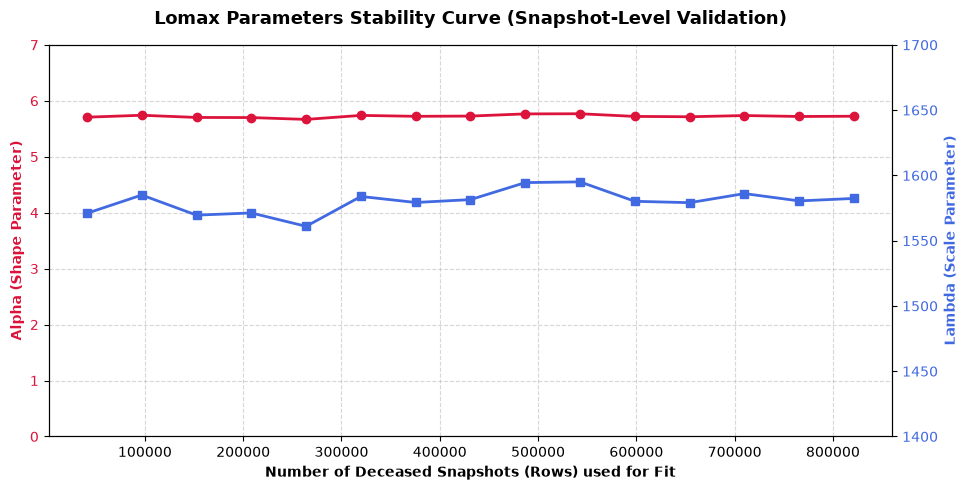

([41072,
  96813,
  152554,
  208295,
  264036,
  319777,
  375519,
  431260,
  487001,
  542742,
  598483,
  654224,
  709965,
  765706,
  821448],
 [np.float64(5.707076385012825),
  np.float64(5.741243713229132),
  np.float64(5.70235743505425),
  np.float64(5.699977141036962),
  np.float64(5.6671991146965786),
  np.float64(5.738867607127651),
  np.float64(5.722380372803772),
  np.float64(5.726819318424303),
  np.float64(5.765692175818231),
  np.float64(5.768085397340824),
  np.float64(5.72073642220708),
  np.float64(5.714622955730615),
  np.float64(5.736216594436124),
  np.float64(5.719417999694732),
  np.float64(5.724099422034684)],
 [np.float64(1570.9774558795618),
  np.float64(1584.9581376201577),
  np.float64(1569.5520057732956),
  np.float64(1571.231268182301),
  np.float64(1560.986715104687),
  np.float64(1583.8649472896805),
  np.float64(1579.2455543330743),
  np.float64(1581.4465309868383),
  np.float64(1594.484902184548),
  np.float64(1595.0279991403916),
  np.float64(1580.1

In [37]:
plot_lomax_stability_curve(data_deces)